In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from src.on import pvals_on, r_stat_on, r_star_on, expected_significance_on
from src.on_off import (
    pvals_onoff,
    asimov_Zs_onoff,
    expected_significance_onoff,
    median_expected_significance_onoff,
)

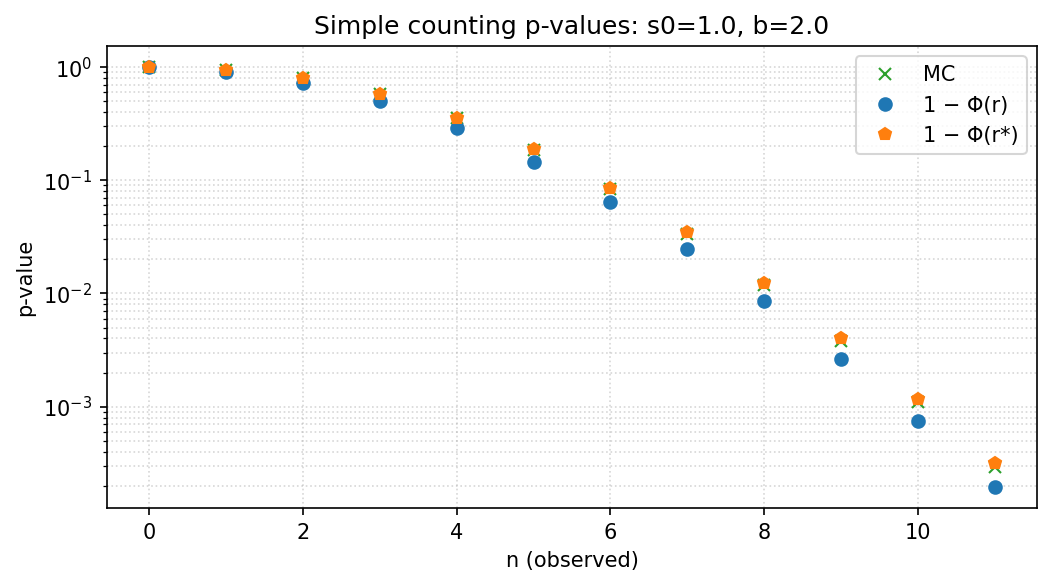

In [7]:
# On: single p-value plot


# Set "true" parameter values
s0 = 1.0
b = 2.0
mu0 = s0 + b

# Observed counts n at which to evaluate p-values
n_vals = np.arange(0, 12)

# Compute p-values with different approximations
p_values = pvals_on(s0, b, n_vals)
p_true = p_values["p_true"]
p_r = p_values["p_r"]
p_rstar = p_values["p_rstar"]

# Plot Monte Carlo and asymptotic p-values as a function of n
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(n_vals, p_true,  marker="x", linestyle="None", label="MC",        color="tab:green")
ax.plot(n_vals, p_r,     marker="o", linestyle="None", label="1 − Φ(r)",  color="tab:blue")
ax.plot(n_vals, p_rstar, marker="p", linestyle="None", label="1 − Φ(r*)", color="tab:orange")
ax.set_yscale("log")
ax.set_xlabel("n (observed)")
ax.set_ylabel("p-value")
ax.set_title(f"Simple counting p-values: s0={s0}, b={b}")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.show()


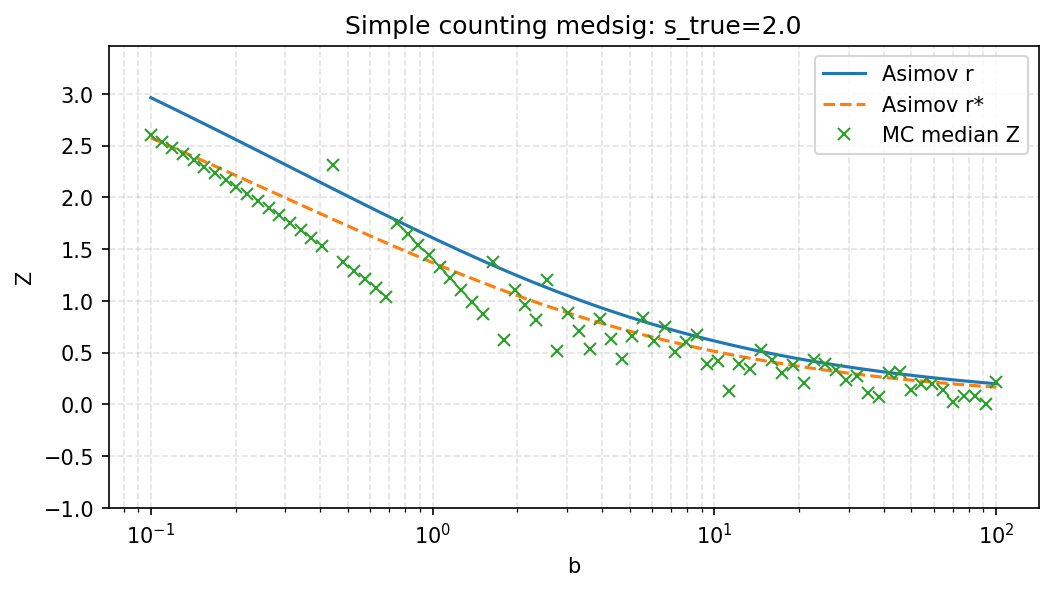

In [8]:
# On: compare expected Z

# Set signal strength and range of background expectations
s_true = 2.0
b_values = np.logspace(-1, 2, 80)

# Compute median expected significances (Asimov r, Asimov r*, and MC)
Z_values = expected_significance_on(s_true, b_values, n_outer=200, seed=12345)
Z_r = Z_values["Z_A_r"]
Z_rstar = Z_values["Z_A_rstar"]
Z_mc = Z_values["Z_mc_median"]

# Plot median expected significances as a function of the background rate
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(b_values, Z_r, label="Asimov r")
ax.plot(b_values, Z_rstar, linestyle="--", label="Asimov r*")
ax.plot(b_values, Z_mc, linestyle="None", marker="x", label="MC median Z")
ax.set_xscale("log")
ax.set_xlabel("b")
ax.set_ylabel("Z")

# Set a sensible y-range based on the curves
Z_max = max(Z_r.max(), Z_rstar.max(), Z_mc.max())
ax.set_ylim(bottom=-1, top=Z_max + 0.5)

ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()
ax.set_title(f"Simple counting medsig: s_true={s_true}")
plt.show()

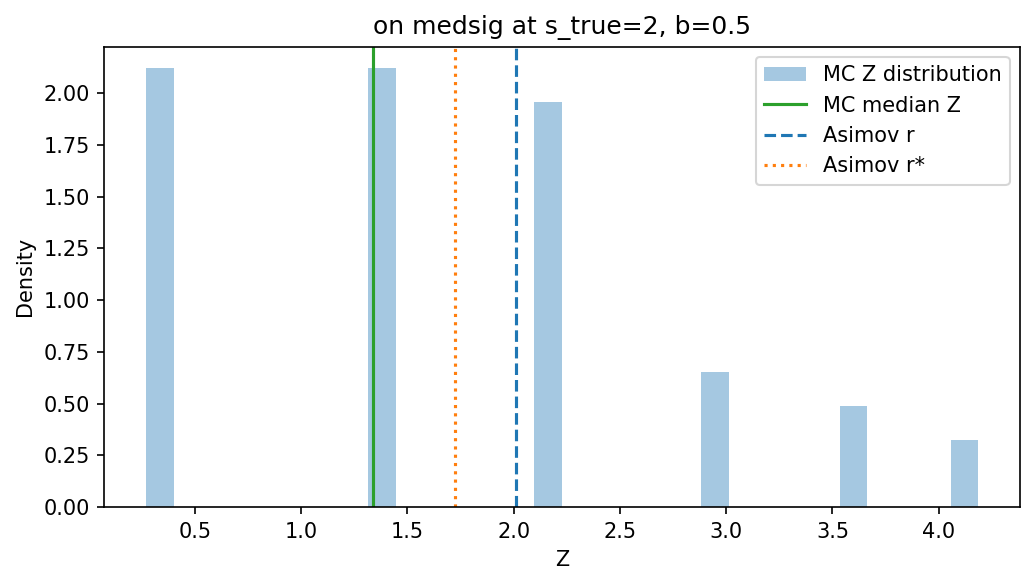

In [23]:
# On: compare MC Z distribution with Asimov Z at one (s_true, b)

s_true = 2
b = 0.5
n_outer = 50
seed = 1234

# Generate toy counts under s_true + b
rng = np.random.default_rng(seed)
Ns = rng.poisson(lam=s_true + b, size=n_outer)

# Exact p-values under H0: s = 0, then Z
p_list = []
for n_obs in Ns:
    p = float(poisson_tail_on(s0=0.0, b=b, n=int(n_obs)))
    p_list.append(p)

# Z from p-values
Z_samples = norm.isf(p_list)  # può contenere ±inf

# Sostituisci ±inf con sentinelle ±999
Z_samples_fixed = np.array(Z_samples, copy=True)
Z_samples_fixed[np.isposinf(Z_samples_fixed)] = 999.0
Z_samples_fixed[np.isneginf(Z_samples_fixed)] = -999.0

# Usa anche i valori estremi (±999) per la mediana
Z_med = float(np.median(Z_samples_fixed))

# Per il plot, escludi solo le sentinelle
mask_plot = (Z_samples_fixed > -999.0) & (Z_samples_fixed < 999.0)
Z_samples_plot = Z_samples_fixed[mask_plot]

# Asimov r and r* at nA = s_true + b
nA = s_true + b
Z_A_r = float(r_stat_on(0.0, b, nA))
Z_A_rstar = float(r_star_on(0.0, b, nA))

# Plot MC Z distribution with Asimov overlays
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.hist(Z_samples_plot, bins=30, density=True, alpha=0.4, label="MC Z distribution")
ax.axvline(Z_med, color="tab:green", label="MC median Z")
ax.axvline(Z_A_r, color="tab:blue", linestyle="--", label="Asimov r")
ax.axvline(Z_A_rstar, color="tab:orange", linestyle=":", label="Asimov r*")
ax.set_xlabel("Z")
ax.set_ylabel("Density")
ax.set_title(f"on medsig at s_true={s_true}, b={b}")
ax.legend()
plt.tight_layout()
plt.show()